In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks

In [18]:
df = pd.read_csv("..\\Data\\2.595.0-Vannstand-inst-v1.csv", skiprows=1, delimiter=';', decimal=',')
df.drop(columns=["Korrigert", "Kontrollert"], inplace=True)
print(len(df))
df.dropna(inplace=True)
df["Tidspunkt"] = pd.to_datetime(df["Tidspunkt"])
df = df.set_index("Tidspunkt").resample("D").max().reset_index()

peaks = find_peaks(df["Vannstand (m)"].values, height=352, distance=30)
exceedances = df["Vannstand (m)"][peaks[0]]
print(f"number of peaks: {len(peaks[0])}")

210374
number of peaks: 49


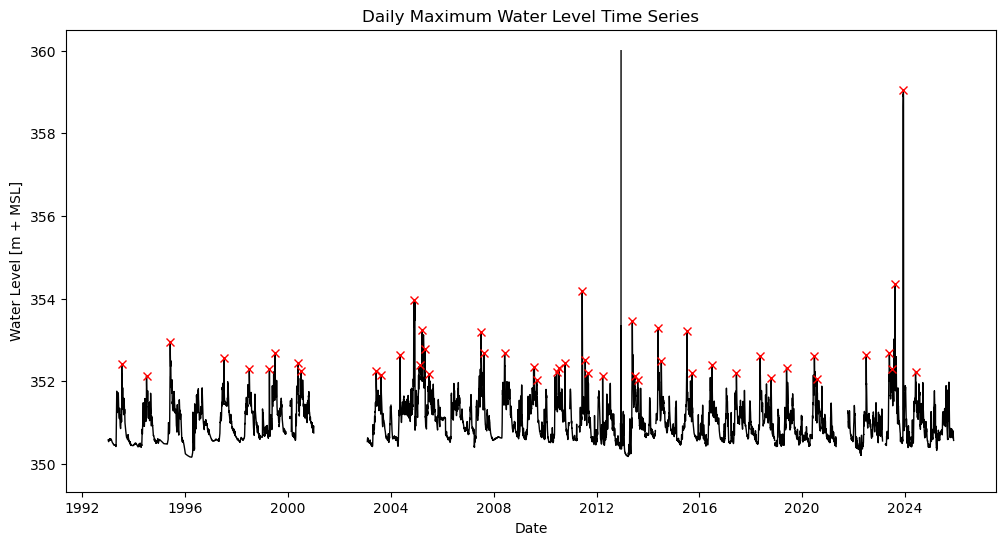

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["Tidspunkt"], df["Vannstand (m)"], label="Water Level", color='black', lw=1)
ax.plot(df["Tidspunkt"].iloc[peaks[0]], exceedances, "x", label="Peaks", color='red')
ax.set_title("Daily Maximum Water Level Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Water Level [m + MSL]")

plt.savefig("..\\Figures\\Waterlevel_analysis_timeseries.png", dpi=300)

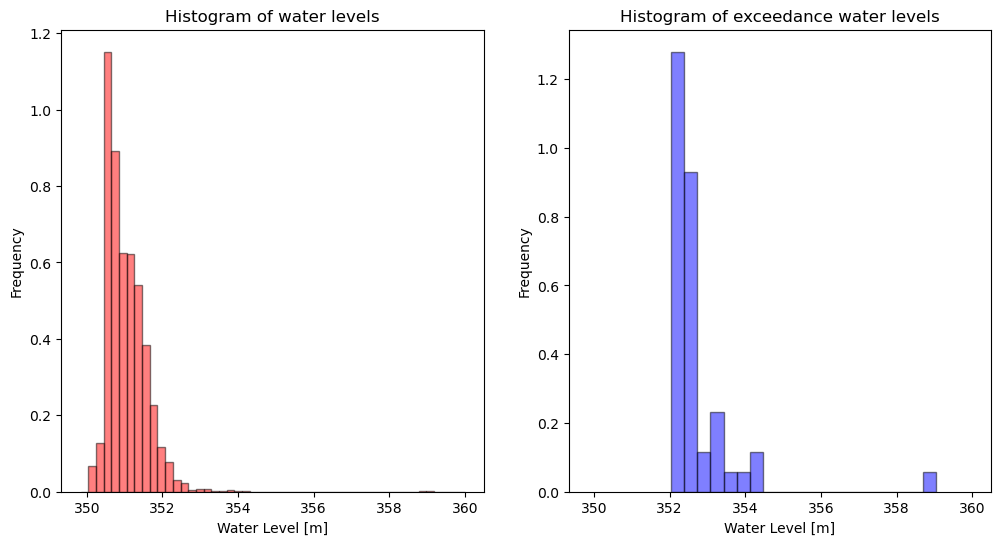

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)

axes[0].hist(df["Vannstand (m)"], bins=50, color='red', edgecolor='black', alpha = 0.5, density=True)
axes[0].set_title("Histogram of water levels")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Water Level [m]")

axes[1].hist(exceedances, bins=20, color='blue', edgecolor='black', alpha = 0.5, density=True)
axes[1].set_title("Histogram of exceedance water levels")
axes[1].set_ylabel("Frequency")
axes[1].set_xlabel("Water Level [m]")

plt.savefig("..\\Figures\\Waterlevel_analysis_hist.png", dpi=300)